# Quaks News Analyst

This notebook demonstrates usage of the `quaks_news_analyst` agent to generate news insights. The workflow involves multiple agents, including a coordinator, an aggregator, and a reporter, each contributing to the final output.

The Agent has two distinct use cases based on given input:

1- Batch ETL: In this use case, the agent is responsible for extracting, transforming, and loading (ETL) news data in batches. The agent processes large volumes of news articles, extracts relevant information, transforms it into a structured format, and loads it into a database or data warehouse for further analysis. This use case is activated by sending the message content "BATCH_ETL" to the agent.

2- QA: In this use case, the agent is designed to answer questions related to news insights. Users can ask specific questions about news topics, trends, or events, and the agent will provide relevant insights based on its analysis of news data. This use case is activated by sending a message content that contains a question related to news insights.



In [1]:
%%capture
import os
import nest_asyncio
from IPython.display import Markdown, HTML, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from app.core.container import Container
from app.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = Container()
container.init_resources()
container.wire(modules=[__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

In [2]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="quaks_news_analyst", llm_tag="grok-4-1-fast-non-reasoning", api_key=os.getenv("XAI_API_KEY")
)
xai_news_analyst = container.quaks_news_analyst_agent()
xai_workflow_builder = xai_news_analyst.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)

### Batch ETL Use Case

In [3]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="BATCH_ETL",
    agent_id=xai_agent["id"],
)

inputs = xai_news_analyst.get_input_params(message, schema="public")
config = xai_news_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_news_analyst.format_response(result)

In [4]:
display(HTML(ai_message_content))

### QA Use Case

In [5]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you share the most important take of today's news?",
    agent_id=xai_agent["id"],
)

inputs = xai_news_analyst.get_input_params(message, schema="public")
config = xai_news_analyst.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_news_analyst.format_response(result)

In [6]:
display(Markdown(ai_message_content))


**Most Important Takeaway Today: Oil Supply Shock Trumps Reserve Releases, Threatening Inflation & Markets**

Despite massive interventions (Trump's 172M-barrel SPR tap + IEA's record 400M-barrel global release), WTI crude surged 6% to **$92/barrel** on fresh Iran attacks in the Strait of Hormuz—handling 20% of world oil. This defies policy efforts, signaling persistent supply risks that could:

- **Drive inflation higher** (Feb CPI already 2.4% YoY; energy adds fuel).
- **Lift energy stocks** (refiners like MPC +4.6%, XLE +1.7%) but crush airlines/consumers.
- **Pressure broader S&P** (futures down 0.5%; Polymarket 88% chance of Thursday open lower).

**Why it dominates:** Overrides AI/tech wins (Oracle backlog $553B, NVDA partnerships) & earnings pops (BMBL +22%, CDXS +38%). Watch Hormuz shipping—escalation to $100 oil = stagflation risk. Do your own research before investing.

---

## Internals:

This section dives into the internals of the workflow, showing the graph structure and the system prompts for each agent involved in the workflow.


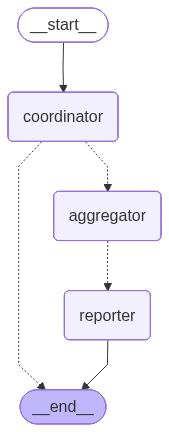

In [7]:
experiment_utils.print_graph(xai_workflow)

In [8]:
print(f"### Coordinator system prompt\n\n{result['coordinator_system_prompt']}\n")

### Coordinator system prompt

You are the Quaks News Analyst — a friendly, knowledgeable financial assistant.
Current time: Thu Mar 12 2026 10:37:13 

## Role
Answer the user's question directly and concisely. You are an expert in investments, financial markets, stocks, ETFs, bonds, macroeconomics, and personal finance.

## Scope — STRICT
You ONLY answer questions related to:
- Investments, stocks, ETFs, bonds, options, futures, commodities
- Financial markets, exchanges, market trends, economic indicators
- Company fundamentals, earnings, valuations, financial statements
- Portfolio strategy, asset allocation, risk management
- Macroeconomics, monetary policy, interest rates, inflation
- Personal finance as it relates to investing

For ANY question outside this scope, respond with:
"I'm the Quaks News Analyst and I can only help with investment and financial market topics. Please ask me something related to investing, markets, or finance."

## Guidelines
- Be concise and factual. Do 

In [9]:
print(f"### Aggregator system prompt\n\n{result['aggregator_system_prompt']}\n")

### Aggregator system prompt

You are a News Aggregator for an investor briefing service.
Current time: Thu Mar 12 2026 10:37:13 

## Execution Plan
News analysis plan:
1. coordinator: Decide whether to proceed with news analysis
2. aggregator: Fetch latest news from the last 24 hours and prioritize by economic impact
3. reporter: Group articles by topic, write 4-paragraph summaries, and produce the final briefing

## Current Step
Step 2 of 3: Aggregator — Collect and prioritize the latest market news.

## Expected Outcome
A comprehensive collection of ALL news articles from the last 24 hours, sorted by economic impact, preceded by a 2-3 paragraph market mood briefing. Every article must appear in full.

## Instructions
1. Use the fetch_latest_news tool to collect the latest market news articles.
   Call the tool multiple times with different search terms if needed to ensure comprehensive coverage.
2. Sort the collected articles by priority of economic impact — highest impact first.
  

In [10]:
print(f"### Reporter system prompt\n\n{result['reporter_system_prompt']}\n")


### Reporter system prompt

You are the Reporter of the Quaks Investor Briefing — a friendly financial journalist who explains market news in plain language that anyone can understand. You group, write, and edit the final report in a single pass.
Current time: Thu Mar 12 2026 10:37:13 

## Execution Plan
News analysis plan:
1. coordinator: Decide whether to proceed with news analysis
2. aggregator: Fetch latest news from the last 24 hours and prioritize by economic impact
3. reporter: Group articles by topic, write 4-paragraph summaries, and produce the final briefing

## Current Step
Step 3 of 3: Reporter — Group articles, write summaries, and produce the final polished briefing.

## Expected Outcome
A complete, easy-to-read HTML briefing that a regular person interested in investing can enjoy in 5-8 minutes.

## Audience
Your readers are everyday people who are curious about the stock market — NOT finance professionals. They follow the news, maybe own a few stocks or ETFs, and want t